In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("samplesuperstore_final.csv", parse_dates=['Order_Date', 'Ship_Date'])

df['Profit Margin'] = df['Profit'] / df['Sales']

def categorize_margin(margin):
    if margin < 0: return 'Loss'
    elif margin < 0.1: return 'Low'
    elif margin < 0.25: return 'Moderate'
    else: return 'High'

df['Profit Category'] = df['Profit Margin'].apply(categorize_margin)

C:\Users\Satyam Shaw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


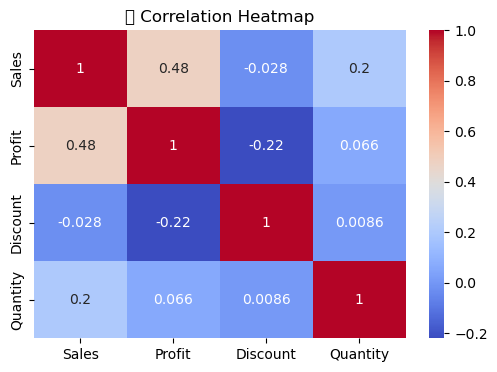

In [3]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Sales', 'Profit', 'Discount', 'Quantity']].corr(), annot=True, cmap='coolwarm')
plt.title("📈 Correlation Heatmap")
plt.show()

C:\Users\Satyam Shaw\AppData\Local\Temp\ipykernel_4068\2598166759.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Category', y='Profit', estimator=sum, ci=None)
C:\Users\Satyam Shaw\AppData\Local\Temp\ipykernel_4068\2598166759.py:7: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Satyam Shaw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


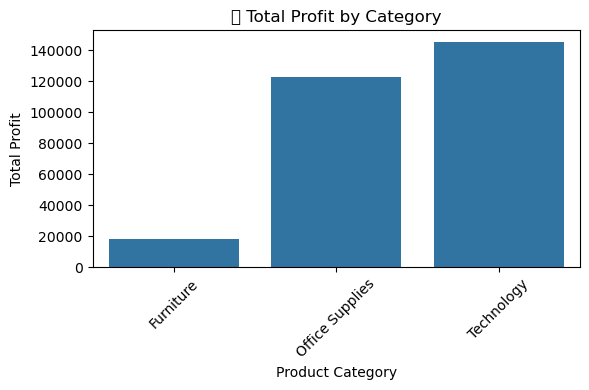

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Category', y='Profit', estimator=sum, ci=None)
plt.title("💰 Total Profit by Category")
plt.ylabel("Total Profit")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Satyam Shaw\AppData\Local\Temp\ipykernel_4068\2498391915.py:9: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Satyam Shaw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


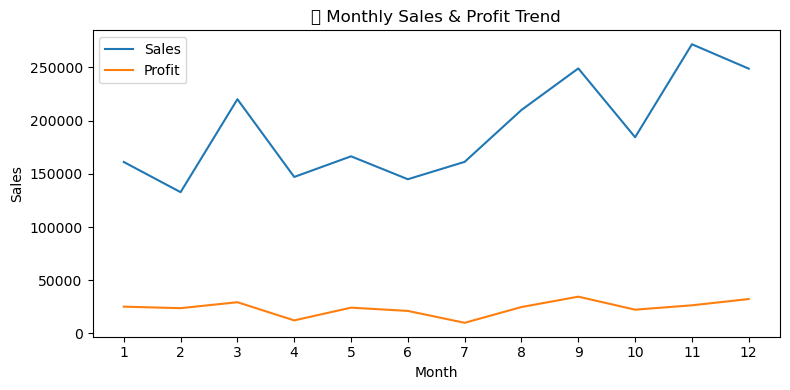

In [5]:
df['Month'] = df['Order_Date'].dt.month
monthly_sales = df.groupby('Month').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', label='Sales')
sns.lineplot(data=monthly_sales, x='Month', y='Profit', label='Profit')
plt.title("📅 Monthly Sales & Profit Trend")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


C:\Users\Satyam Shaw\AppData\Local\Temp\ipykernel_4068\1309004033.py:4: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Satyam Shaw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


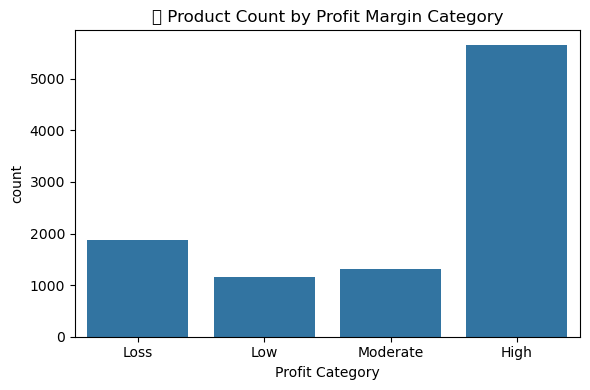

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Profit Category', order=['Loss', 'Low', 'Moderate', 'High'])
plt.title("🧮 Product Count by Profit Margin Category")
plt.tight_layout()
plt.show()

In [7]:
df.to_csv("D:/New folder/Uploads/RetailProfitOptimization.csv", index=False)